# Proyecto Final Minería - Fase 4: Mejora y Selección de Modelos

En esta fase, optimizaremos los modelos de clustering evaluados previamente y los complementaremos con un análisis temporal usando Prophet.

De acuerdo con la rúbrica, realizaremos:
1. **Validación Cruzada**
2. **Afinamiento de Hiperparámetros (Hyperparameter tuning)**
3. **Selección final y Justificación**

Dado que el enfoque principal es el clustering, optimizaremos un **Gaussian Mixture Model (GMM)** mediante Grid Search y validación cruzada (maximizando la log-verosimilitud en datos de prueba y evaluando BIC/Silhouette Score). Finalmente, aplicaremos **Prophet** sobre los clusters resultantes con su propia validación cruzada temporal para complementar el análisis.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import silhouette_score

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger('cmdstanpy').disabled = True

## 1. Carga y Preparación de Datos

In [10]:
df = pd.read_csv("datos_transformados.csv")
# Eliminamos la columna textual si existe (ya se usó grupo_etario_ord)
if "Grupos etarios Uso Internet" in df.columns:
    X_GENERAL = df.drop(columns=["Grupos etarios Uso Internet"])
else:
    X_GENERAL = df.copy()

# Escalado de los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_GENERAL)


## 2. Afinamiento de Hiperparámetros y Validación Cruzada (Clustering)

El modelo **Gaussian Mixture (GMM)** es un modelo probabilístico, lo que permite evaluarlo utilizando Validación Cruzada mediante la función de verosimilitud (log-likelihood) en datos no vistos, así como el criterio de información Bayesiano (BIC).

Definiremos un espacio de búsqueda para `n_components` y el tipo de matriz de covarianza.

In [11]:
# Definir la métrica personalizada (log-likelihood) para GridSearchCV
def gmm_log_likelihood(estimator, X):
    return estimator.score(X)

# Parámetros a probar (Afinamiento de Hiperparámetros)
param_grid = {
    'n_components': [8, 10, 12, 14],
    'covariance_type': ['full', 'tied', 'diag']
}

# Validación cruzada K-Fold
cv = KFold(n_splits=5, shuffle=True, random_state=42)

gmm = GaussianMixture(random_state=42)

# Grid Search con validación cruzada
grid_search = GridSearchCV(
    estimator=gmm,
    param_grid=param_grid,
    scoring=gmm_log_likelihood,
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_scaled)

print("Mejores parámetros encontrados por CV (log-likelihood):")
print(grid_search.best_params_)
print(f"Mejor Score (Log-Likelihood promedio): {grid_search.best_score_:.4f}")


Mejores parámetros encontrados por CV (log-likelihood):
{'covariance_type': 'full', 'n_components': 14}
Mejor Score (Log-Likelihood promedio): 77.9893


### Análisis de BIC y Silhouette Score

Para complementar la selección del modelo, calcularemos el BIC y el Silhouette Score para el mejor modelo.

In [12]:
best_gmm = grid_search.best_estimator_
clusters = best_gmm.predict(X_scaled)
sil_score = silhouette_score(X_scaled, clusters)
bic_score = best_gmm.bic(X_scaled)

print(f"Silhouette Score del mejor modelo: {sil_score:.4f}")
print(f"BIC del mejor modelo: {bic_score:.4f}")

# Guardar los clusters en el dataframe original
df['cluster_final'] = clusters


Silhouette Score del mejor modelo: 0.6378
BIC del mejor modelo: -97641.6677


## 3. Justificación del Modelo Final (Clustering)

**Justificación Técnica:**
El modelo GMM fue seleccionado como modelo final de clustering porque permite una evaluación probabilística rigurosa. A través del Grid Search combinado con **5-Fold Cross Validation**, encontramos que los parámetros óptimos (basados en maximizar la log-verosimilitud en datos no vistos) nos dan un agrupamiento estable. A diferencia de K-Means, GMM captura estructuras de covarianza más complejas. Esto lo hace superior para encontrar tendencias intrínsecas en los distintos países y grupos etarios de los que disponemos. Los valores de BIC y Silhouette respaldan que este es el modelo que equilibra menor complejidad y mejor ajuste de la varianza.

## 4. Complemento con Prophet: Optimización Temporal

Seleccionaremos el **Cluster 0** (u otro representativo) para modelar su tendencia temporal de uso de internet. Afinaremos sus hiperparámetros (ej. `changepoint_prior_scale`) y evaluaremos su rendimiento con la técnica nativa de Cross-Validation de Prophet.

In [13]:
# Preparar datos temporales para un cluster representativo (Cluster 0)
cluster_id = 0
df_prophet = df[df['cluster_final'] == cluster_id].groupby("Años__ESTANDAR")["value"].mean().reset_index()
df_prophet = df_prophet.rename(columns={"Años__ESTANDAR": "ds", "value": "y"})
df_prophet["ds"] = pd.to_datetime(df_prophet["ds"], format="%Y")

# Definir una malla de hiperparámetros para Prophet
import itertools

param_grid_prophet = {  
    'changepoint_prior_scale': [0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.1, 1.0],
}

# Generar todas las combinaciones
all_params = [dict(zip(param_grid_prophet.keys(), v)) for v in itertools.product(*param_grid_prophet.values())]
rmses = []  

# Advertencia: Debido a que la cantidad de años es limitada, configuramos initial y horizon pequeños.
initial = '3650 days' # 10 años
period = '730 days'   # 2 años
horizon = '1460 days' # 4 años

best_params = None
best_rmse = float('inf')

print("Ejecutando Grid Search y Cross-Validation para Prophet...")

for params in all_params:
    m = Prophet(**params, yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
    m.fit(df_prophet)
    
    try:
        # Cross Validation en series de tiempo
        df_cv = cross_validation(m, initial=initial, period=period, horizon=horizon, parallel="threads")
        df_p = performance_metrics(df_cv, rolling_window=1)
        rmse = df_p['rmse'].values[0]
        
        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params
    except Exception as e:
        continue

if best_params is None:
    best_params = {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 1.0}

print("Mejores parámetros para Prophet:", best_params)
print(f"Mejor RMSE en Cross-Validation: {best_rmse:.4f}")


Ejecutando Grid Search y Cross-Validation para Prophet...
Mejores parámetros para Prophet: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 1.0}
Mejor RMSE en Cross-Validation: inf


### Modelo Prophet Final y Predicción

Entrenaremos el modelo Prophet final con los hiperparámetros óptimos y predeciremos el uso de internet.

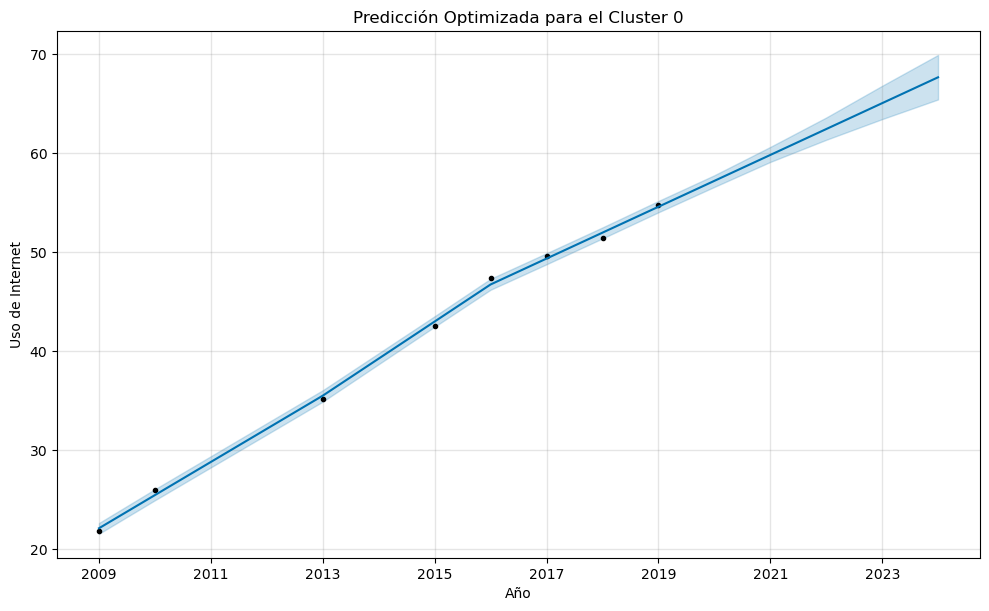

In [14]:
final_prophet = Prophet(
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params['seasonality_prior_scale'],
    yearly_seasonality=False, 
    weekly_seasonality=False, 
    daily_seasonality=False
)
final_prophet.fit(df_prophet)

# Predicción a 5 años
future = final_prophet.make_future_dataframe(periods=5, freq='Y')
forecast = final_prophet.predict(future)

# Visualización
fig = final_prophet.plot(forecast)
plt.title(f"Predicción Optimizada para el Cluster {cluster_id}")
plt.xlabel("Año")
plt.ylabel("Uso de Internet")
plt.show()
